# Gaussian Cubature Error

Compare IID samples and stationary MMD-flow points for integrating a Gaussian RKHS test function under a standard 2D Gaussian target.

In [24]:
import os
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

os.chdir("/home/zongchen/stationary_mmd_slides")
jax.config.update("jax_enable_x64", True)

plt.rcParams["axes.grid"] = True
plt.rcParams["font.family"] = "DeJavu Serif"
plt.rcParams["font.serif"] = ["Times New Roman"]
plt.rc("text", usetex=True)
plt.rc("text.latex", preamble=r"\usepackage{amsmath, amsfonts}")
plt.rc("axes", titlesize=18, labelsize=18, grid=True)
plt.rc("lines", linewidth=2)
plt.rc("legend", fontsize=14, frameon=False)
plt.rc("xtick", labelsize=14, direction="in")
plt.rc("ytick", labelsize=14, direction="in")


In [25]:
try:
    devices = jax.devices("gpu")
except RuntimeError as err:
    raise RuntimeError(
        "No JAX GPU device is visible. Run this notebook in the thin_mfld environment "
        "where nvidia-smi works and JAX can see CUDA."
    ) from err

if not devices:
    raise RuntimeError("No JAX GPU device is visible to JAX.")

device = devices[0]
device


CudaDevice(id=0)

In [26]:
gaussian_dim = 2
gaussian_sigma = 0.45
gaussian_step_size = 6.0
gaussian_steps = 10000
n_values = np.array([16, 32, 64, 128, 256, 512])

mmd_replicates = 8
iid_replicates = 512
rkhs_center = jnp.array([0.85, -0.65], dtype=jnp.float64)


def gaussian_kernel_mean_to_standard_normal(x, bandwidth):
    scale = (bandwidth**2 / (bandwidth**2 + 1.0)) ** (gaussian_dim / 2)
    return scale * jnp.exp(-0.5 * jnp.sum(x**2, axis=-1) / (bandwidth**2 + 1.0))


true_integral = gaussian_kernel_mean_to_standard_normal(rkhs_center[None, :], gaussian_sigma)[0]


@jax.jit
def rkhs_function(x):
    diff = x - rkhs_center
    return jnp.exp(-0.5 * jnp.sum(diff**2, axis=-1) / gaussian_sigma**2)


@jax.jit
def batched_integration_error(x):
    return jnp.abs(jnp.mean(rkhs_function(x), axis=1) - true_integral)


@jax.jit
def batched_population_mmd2_gradient(x):
    n = x.shape[1]
    diff = x[:, :, None, :] - x[:, None, :, :]
    k_xx = jnp.exp(-0.5 * jnp.sum(diff**2, axis=-1) / gaussian_sigma**2)
    repulsion_grad = -(2.0 / (n**2 * gaussian_sigma**2)) * jnp.sum(
        k_xx[..., None] * diff,
        axis=2,
    )
    mean_embed = gaussian_kernel_mean_to_standard_normal(x, gaussian_sigma)
    attraction_grad = (2.0 / n) * (x / (gaussian_sigma**2 + 1.0)) * mean_embed[..., None]
    return repulsion_grad + attraction_grad


@jax.jit
def batched_gaussian_flow_step(x):
    return x - gaussian_step_size * batched_population_mmd2_gradient(x)


In [27]:
iid_error_quantiles = []
mmd_error_quantiles = []

master_key = jax.random.PRNGKey(10)

for n in tqdm(n_values, desc="Point counts"):
    master_key, key_iid, key_mmd = jax.random.split(master_key, 3)
    with jax.default_device(device):
        iid_samples = jax.random.normal(
            key_iid,
            (iid_replicates, int(n), gaussian_dim),
            dtype=jnp.float64,
        )
        x_mmd = 0.35 * jax.random.normal(
            key_mmd,
            (mmd_replicates, int(n), gaussian_dim),
            dtype=jnp.float64,
        )

    iid_errors = np.asarray(jax.device_get(batched_integration_error(iid_samples)))
    iid_error_quantiles.append(np.quantile(iid_errors, [0.1, 0.5, 0.9]))

    progress = tqdm(range(gaussian_steps), desc=f"MMD flow n={n}", leave=False)
    for step in progress:
        x_mmd = batched_gaussian_flow_step(x_mmd)
        if (step + 1) % 100 == 0:
            x_mmd.block_until_ready()
    x_mmd.block_until_ready()

    mmd_errors = np.asarray(jax.device_get(batched_integration_error(x_mmd)))
    mmd_error_quantiles.append(np.quantile(mmd_errors, [0.1, 0.5, 0.9]))

iid_error_quantiles = np.asarray(iid_error_quantiles)
mmd_error_quantiles = np.asarray(mmd_error_quantiles)


Point counts: 100%|██████████| 6/6 [00:04<00:00,  1.43it/s]


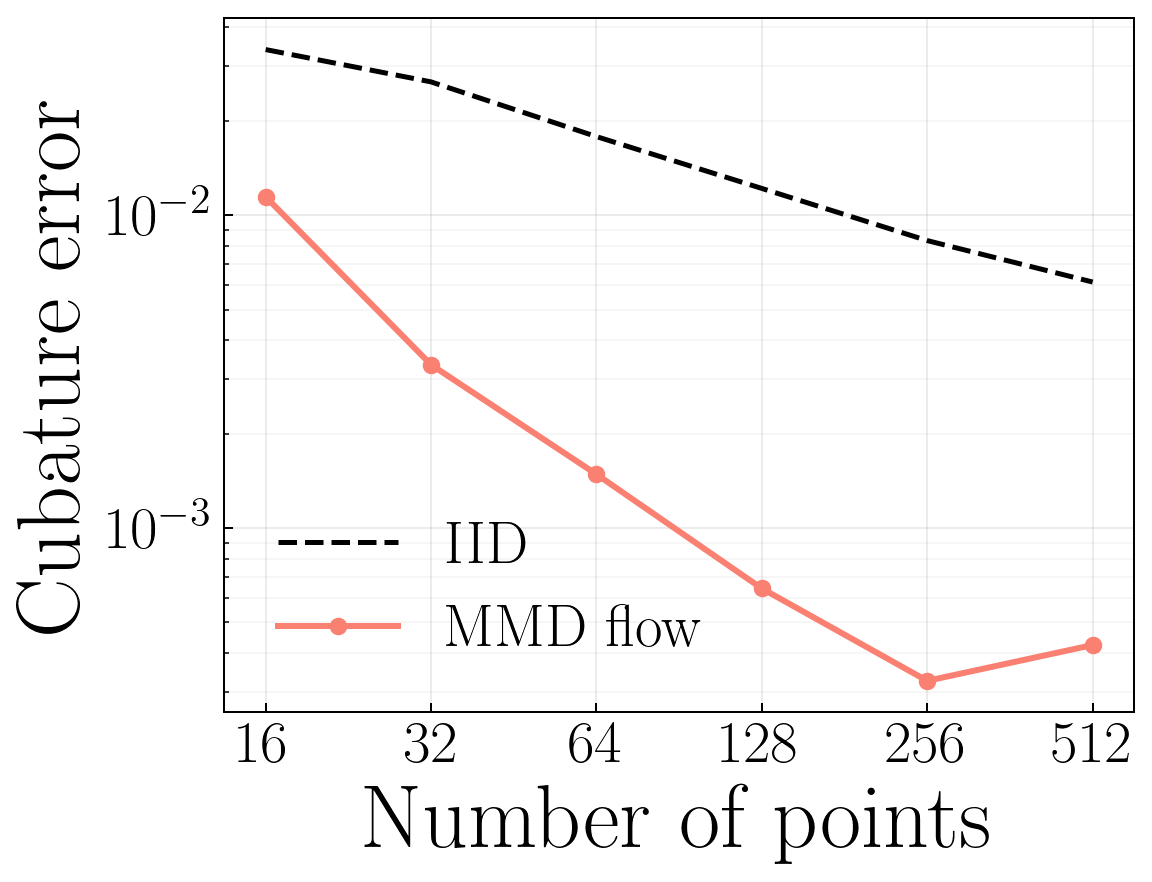

In [28]:
fig, ax = plt.subplots(figsize=(8.0, 5), dpi=180)

ax.plot(n_values, iid_error_quantiles[:, 1], "--", color="black", linewidth=2.0, label="IID")

ax.plot(n_values, mmd_error_quantiles[:, 1], "o-", color="salmon", linewidth=2.4, label="MMD flow")

ax.set_xscale("log", base=2)
ax.set_yscale("log")
ax.set_xticks(n_values)
ax.set_xticklabels([str(n) for n in n_values], fontsize=24)
ax.tick_params(axis="y", labelsize=24)
ax.set_xlabel("Number of points", fontsize=36)
ax.set_ylabel("Cubature error", fontsize=36)
ax.grid(True, which="major", alpha=0.25)
ax.grid(True, which="minor", alpha=0.10)
ax.legend(loc="best", fontsize=24)

fig.tight_layout()
save_path = "/home/zongchen/stationary_mmd_slides/figures/gaussian_cubature_error.pdf"
os.makedirs(os.path.dirname(save_path), exist_ok=True)
fig.savefig(save_path, bbox_inches="tight")
plt.show()
